Caso 1: análisis cartera de OPS

Se realizará un análisis a la cartera de clientes de OPS con los siguientes objetivos:

1) Identificar señales de riesgo o desenganche, como caída de conversaciones respecto a su rubro, baja actividad en el panel, problemas técnicos o clientes nuevos que no despegan. Luego, ordenar esos casos por prioridad y entregar un motivo de contacto concreto basado en datos.

2) Identificar clientes cuyo uso supera de forma sostenida el límite de su plan, estimar si existe una oportunidad de upsell y cuantificar el MRR e ingreso anual potencial asociado.


Comenzamos importando las librerías pandas, numpy y matplotlib. Además de los csv de uso_mensual y clientes

In [1395]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

uso = pd.read_csv("./uso_mensual.csv")
clientes = pd.read_csv("./clientes.csv")

print("uso:", uso.shape)
print("clientes:", clientes.shape)


uso: (606, 26)
clientes: (140, 12)


Aquí podemos revisar las dimensiones, 606 filas para uso y 26 columnas, y para clientes 140 filas (es decir 140 clientes) y 12 columnas

Revisamos las columnas para saber con qué datos vamos a trabajar

In [1396]:
print(uso.columns.tolist())
print(clientes.columns.tolist())

['cliente_id', 'cliente', 'mes', 'plan', 'mrr_usd', 'conversaciones', 'resueltas_por_agente', 'derivadas_a_humano', 'derivadas_sin_respuesta', 'seg_respuesta_agente', 'carritos_recuperados', 'ventas_atribuidas_usd', 'sesiones_panel', 'dias_activos_panel', 'usuarios_activos_panel', 'usuarios_cuenta', 'cambios_configuracion', 'horas_respuesta_equipo', 'tickets_soporte', 'tickets_reabiertos', 'errores_integracion', 'dias_agente_inactivo', 'productos_sincronizados', 'mensajes_no_entregados', 'canales_activos', 'dias_pago_atrasado']
['cliente_id', 'cliente', 'rubro', 'pais', 'cms', 'plan_actual', 'fecha_checkout', 'ops_owner', 'estado', 'contacto_nombre', 'contacto_email', 'telefono']


Paso 0: Limpieza de datos

Revisamos los datos nulos de cada columna

In [1397]:
print("Nulos uso:")
display(uso.isna().sum().sort_values(ascending=False))

print("Nulos clientes:")
display(clientes.isna().sum().sort_values(ascending=False))

print("Duplicados cliente-mes:",
      uso.duplicated(subset=["cliente_id", "mes"]).sum())

print("IDs duplicados en clientes:",
      clientes["cliente_id"].duplicated().sum())

Nulos uso:


productos_sincronizados    15
usuarios_activos_panel     12
mes                         0
plan                        0
mrr_usd                     0
conversaciones              0
resueltas_por_agente        0
derivadas_a_humano          0
cliente_id                  0
cliente                     0
seg_respuesta_agente        0
derivadas_sin_respuesta     0
sesiones_panel              0
carritos_recuperados        0
dias_activos_panel          0
usuarios_cuenta             0
cambios_configuracion       0
ventas_atribuidas_usd       0
horas_respuesta_equipo      0
tickets_soporte             0
errores_integracion         0
tickets_reabiertos          0
dias_agente_inactivo        0
mensajes_no_entregados      0
canales_activos             0
dias_pago_atrasado          0
dtype: int64

Nulos clientes:


fecha_checkout     8
cliente_id         0
rubro              0
cliente            0
pais               0
cms                0
plan_actual        0
ops_owner          0
estado             0
contacto_nombre    0
contacto_email     0
telefono           0
dtype: int64

Duplicados cliente-mes: 0
IDs duplicados en clientes: 0


Vemos que tenemos 15 valores nulos en productos sincronizados y 12 en usuarios activos, y por otro lado 8 en fecha_checkout, hay que ver entonces si existe relación con otro dato

In [1398]:
display(clientes["estado"].value_counts())

estado
Activo               132
En implementación      8
Name: count, dtype: int64

Justo vemos que son 8 clientes en implementación, revisamos si la columna "fecha_checkout" tiene relación al estado del cliente

In [1399]:
i=0
for k in clientes["estado"]:
    if k=="En implementación":
        print(clientes['fecha_checkout'][i])
    i+=1

nan
nan
nan
nan
nan
nan
nan
nan


Con esto comprobamos que los valores faltantes de fecha_checkout que no están es porque están en implementación.

Revisamos la cantidad de meses con la que ha tratado cada cliente

In [1400]:
print(uso["mes"].value_counts().sort_index())

historia = (
    uso.groupby("cliente_id")
       .agg(
           primer_mes=("mes", "min"),
           ultimo_mes=("mes", "max"),
           meses_historia=("mes", "count")
       )
       .reset_index()
)

display(historia["meses_historia"].value_counts())

mes
2026-05    114
2026-06    114
2026-07    114
2026-08    132
2026-09    132
Name: count, dtype: int64


meses_historia
5    114
2     18
Name: count, dtype: int64

Vemos que hay 114 clientes con 5 meses de historia y solo 18 clientes nuevos con menos de 2 meses de historia

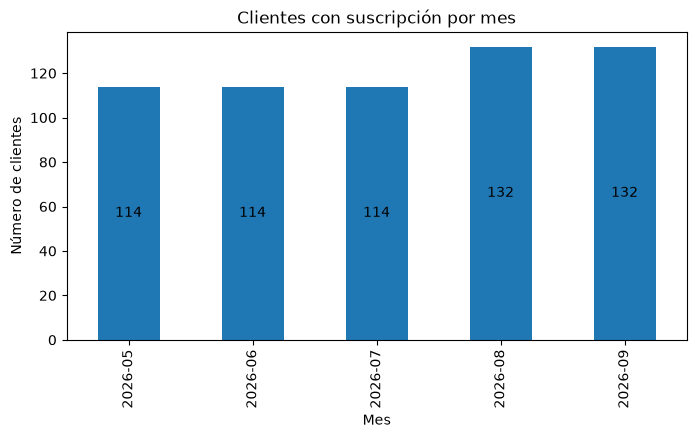

In [1401]:
clientes_por_mes = uso.groupby("mes")["cliente_id"].nunique()

ax = clientes_por_mes.plot(
    kind="bar",
    figsize=(8, 4),
    title="Clientes con suscripción por mes"
)

plt.ylabel("Número de clientes")
plt.xlabel("Mes")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center"
    )

plt.show()

Gráfica 1: cantidad de clientes con subcripción por mes

Ahí vemos gráficamente como han variado los clientes, vemos que en los últimos 2 meses fue cuando se integraron los 18 clientes nuevos, esto últimos hay que tratarlos de manera diferente.

Ahora transformamos las fechas en tipo datetime

In [1402]:
clientes["fecha_checkout_dt"] = pd.to_datetime(
    clientes["fecha_checkout"],
    errors="coerce"
)

uso["mes_dt"] = pd.to_datetime(
    uso["mes"] + "-01"
)

Ahora generamos un solo DataFrame para tener toda la información de los clientes 

In [1403]:
columnas_cliente = [
    "cliente_id",
    "rubro",
    "pais",
    "cms",
    "plan_actual",
    "fecha_checkout_dt",
    "ops_owner",
    "estado",
    "contacto_nombre",
    "contacto_email"
]
#unimos uso con clientes usando merge, para tener toda la información en un solo dataframe
df = uso.merge(
    clientes[columnas_cliente],
    on="cliente_id",
    how="left",
    validate="many_to_one"
)

print("Filas en uso:", len(uso))
print("Filas en df:", len(df))

display(df.head())

Filas en uso: 606
Filas en df: 606


,cliente_id,cliente,mes,plan,mrr_usd,conversaciones,resueltas_por_agente,derivadas_a_humano,derivadas_sin_respuesta,seg_respuesta_agente,...,mes_dt,rubro,pais,cms,plan_actual,fecha_checkout_dt,ops_owner,estado,contacto_nombre,contacto_email
0,VSU-0001,Andes Mascotas,2026-05,Starter,149,276,247,29,1,3,...,2026-05-01,mascotas,Colombia,Shopify,Starter,2025-02-26,Ops 2,Activo,Andrés Herrera,andres@andesmascotas.cl
1,VSU-0001,Andes Mascotas,2026-06,Starter,149,236,215,21,0,3,...,2026-06-01,mascotas,Colombia,Shopify,Starter,2025-02-26,Ops 2,Activo,Andrés Herrera,andres@andesmascotas.cl
2,VSU-0001,Andes Mascotas,2026-07,Starter,149,215,173,42,0,3,...,2026-07-01,mascotas,Colombia,Shopify,Starter,2025-02-26,Ops 2,Activo,Andrés Herrera,andres@andesmascotas.cl
3,VSU-0001,Andes Mascotas,2026-08,Starter,149,226,180,46,1,4,...,2026-08-01,mascotas,Colombia,Shopify,Starter,2025-02-26,Ops 2,Activo,Andrés Herrera,andres@andesmascotas.cl
4,VSU-0001,Andes Mascotas,2026-09,Starter,149,149,128,21,2,6,...,2026-09-01,mascotas,Colombia,Shopify,Starter,2025-02-26,Ops 2,Activo,Andrés Herrera,andres@andesmascotas.cl


Ya vemos que tenemos una sola lista que une ambas listas anteriores

Definimos la fecha de corte como el 21 de septiembre que fue la fecha que fue extraída los datos

Finalmente extrapolamos las conversaciones de septiembre a como si hubieran pasado los 30 días

In [1404]:
FECHA_CORTE = pd.Timestamp("2026-09-21")

df["conversaciones_ajustadas"] = df["conversaciones"].astype(float)

mask_sep = df["mes"] == "2026-09"

df.loc[mask_sep, "conversaciones_ajustadas"] = (
    df.loc[mask_sep, "conversaciones"]
    * 30
    / 21
)

Comprobamos que no hayan aumentado las filas

In [1405]:
len(uso), len(clientes), len(df)

(606, 140, 606)

Paso 1: definir la antigüedad de los clientes

Ahora queremos separar la continuidad de cada cliente para separarlo entre antiguos y nuevos, así tenemos otra referencia de su comportamiento

In [1406]:
fecha_corte = pd.Timestamp("2026-09-21")

df["antiguedad_dias"] = (
    fecha_corte - df["fecha_checkout_dt"]
).dt.days

df["antiguedad_meses"] = (
    df["antiguedad_dias"] / 30.44 #días promedio por mes
)

Vemos la tabla ordenada del cliente más nuevo al más antiguo y eliminamos duplicado debido a que df tiene el comportamiento mensual del cliente

In [1407]:
display(
    df[
        [
            "cliente",
            "fecha_checkout_dt",
            "antiguedad_dias",
            "antiguedad_meses",
            "estado"
        ]
    ]
    .drop_duplicates("cliente")
    .sort_values("antiguedad_meses")
    .head(8)
)

,cliente,fecha_checkout_dt,antiguedad_dias,antiguedad_meses,estado
465,Tostaduría Café,2026-08-17,35,1.149803,Activo
217,Hidra Montaña,2026-08-16,36,1.182654,Activo
411,Quinta Cerámica,2026-08-16,36,1.182654,Activo
123,Ergo Vital,2026-08-08,44,1.445466,Activo
433,Rústico Store,2026-08-08,44,1.445466,Activo
165,Fiorella Montaña,2026-07-31,52,1.708279,Activo
34,Bloom Surf,2026-07-29,54,1.773982,Activo
17,Aura Lauret,2026-07-28,55,1.806833,Activo


Realizamos una función para catalogar al cliente de Nuevo si lleva menos de 4 meses, o Maduro  si lleva al menos 4 meses.

In [1408]:
def clasificar_cliente(fila):
    if fila["estado"] == "En implementación":
        return "En implementación"
    elif fila["antiguedad_meses"] < 4:
        return "Nuevo"
    else:
        return "Maduro"

df["etapa_cliente"] = df.apply(
    clasificar_cliente,
    axis=1
)

Observamos cuántos clientes Maduros y Nuevos tenemos

In [1409]:
df[
    ["cliente_id", "etapa_cliente"]
].drop_duplicates()["etapa_cliente"].value_counts()

etapa_cliente
Maduro    113
Nuevo      19
Name: count, dtype: int64

Aquí ya tenemos nuestra lista de clientes definiendo cuál es un cliente con antiguedad y cual es nuevo. Definiendo que los clientes sobre 4 meses de antiguedad se consideran maduros

Paso 2: definir comportamiento de clientes en comparación a su rubro

Ahora contruiremos una referencia de como es un cliente que se comporta de manera "Normal"
Para esto solo nos interesan los clientes Activos, Maduros y de meses completos de mayo a agosto

In [1410]:
meses_completos = ["2026-05", "2026-06", "2026-07", "2026-08"]

df_maduros = df[
    (df["estado"] == "Activo") &
    (df["etapa_cliente"] == "Maduro") &
    (df["mes"].isin(meses_completos))
].copy()

Obtenemos la mediana de las convesaciones, las sesiones en el panel y los días que se entró al panel y los separamos según el plan que se contrató

In [1411]:
referencia_plan = (
    df_maduros
    .groupby("plan")
    .agg(
        conversaciones_p25=("conversaciones", lambda x: x.quantile(0.25)),
        conversaciones_mediana=("conversaciones", "median"),
        conversaciones_p75=("conversaciones", lambda x: x.quantile(0.75)),

        sesiones_panel_p25=("sesiones_panel", lambda x: x.quantile(0.25)),
        sesiones_panel_mediana=("sesiones_panel", "median"),
        sesiones_panel_p75=("sesiones_panel", lambda x: x.quantile(0.75)),

        dias_panel_mediana=("dias_activos_panel", "median"),
        ventas_mediana=("ventas_atribuidas_usd", "median"),

        clientes=("cliente_id", "nunique")
    )
)

display(referencia_plan)

,conversaciones_p25,conversaciones_mediana,conversaciones_p75,sesiones_panel_p25,sesiones_panel_mediana,sesiones_panel_p75,dias_panel_mediana,ventas_mediana,clientes
plan,,,,,,,,,
Max,2970.0,3675.5,4439.25,6.0,11.5,16.75,6.0,10356.075,25
Pro,823.0,1045.5,1383.00,7.0,13.0,18.00,7.5,3069.055,43
Starter,214.5,264.5,345.00,5.0,9.0,16.00,5.0,678.640,46


Con esto tenemos una referencia de como se comporta los percentiles para las conversaciones y las sesiones

Ahora vamos a analizar el comportamiento de cada rubro, buscando conocer más cuando se puede tratar de una caída. Evitando catalogar de mala manera una variación en la conversaciones

In [1412]:
rubro_mes = (
    df_maduros
    .groupby(["rubro", "mes"])
    .agg(
        conversaciones_mediana=("conversaciones", "median"),
        clientes=("cliente_id", "nunique")
    )
    .reset_index()
)


Hacemos la variación de julio a agosto que es la más reciente y nos interesa más calcularla

In [1413]:
comparacion_rubro = (
    rubro_mes[
        rubro_mes["mes"].isin(["2026-07", "2026-08"])
    ]
    .pivot(
        index="rubro",
        columns="mes",
        values="conversaciones_mediana"
    )
)

Finalmente tenemos una variación de cada rubro entre los meses de julio a agosto

In [1414]:
comparacion_rubro["variacion_pct"] = (
    (
        comparacion_rubro["2026-08"]
        / comparacion_rubro["2026-07"]
    ) - 1
) * 100

display(
    comparacion_rubro.sort_values("variacion_pct")
)

mes,2026-07,2026-08,variacion_pct
rubro,,,
regalos,989.5,530.5,-46.387064
juguetes,812.0,473.0,-41.748768
vinos,768.5,541.0,-29.603123
decohogar,1081.0,922.0,-14.708603
ferretería,402.0,350.0,-12.935323
repuestos,849.0,772.0,-9.069494
cosmética,1146.5,1188.5,3.663323
nutrición,994.0,1031.5,3.772636
deportes,603.5,644.5,6.793703


De manera gráfica:

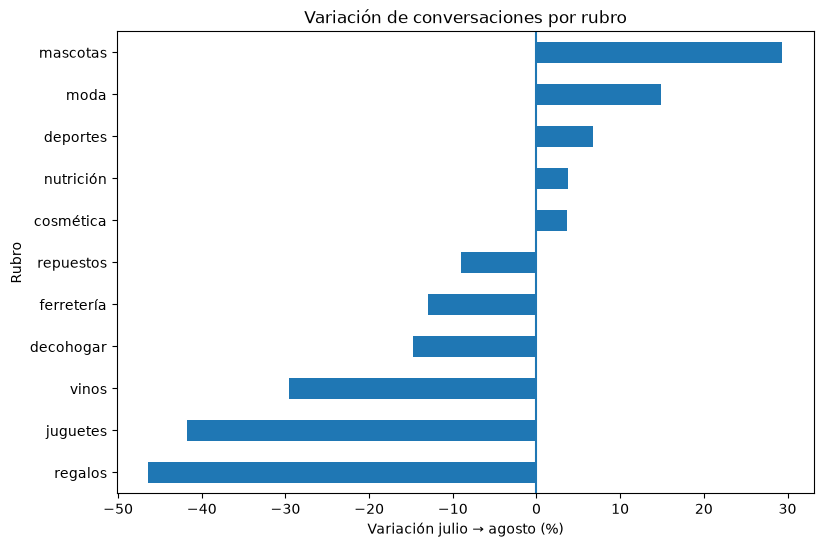

In [1415]:
import matplotlib.pyplot as plt

comparacion_rubro["variacion_pct"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.axvline(0)
plt.xlabel("Variación julio → agosto (%)")
plt.ylabel("Rubro")
plt.title("Variación de conversaciones por rubro")

plt.show()

Gráfica 2: variación porcentual de julio a agosto según rubro

Así, ya conociendo el comportamiento de cada rubro, podemos identificar si la caída de conversaciones de un cliente es un dato preocupante o no

Ahora para cada cliente con caída de conversaciones nos podemos preguntar: “¿Este cliente cayó porque todo su rubro cayó, o se está comportando peor que clientes comparables?”

Dejamos las conversaciones de julio y agosto una al lado de otra

In [1416]:
cliente_mes = (
    df_maduros[
        df_maduros["mes"].isin(["2026-07", "2026-08"])
    ]
    .pivot(
        index=["cliente_id", "cliente", "rubro"],
        columns="mes",
        values="conversaciones"
    )
    .reset_index()
)

display(cliente_mes.head())

mes,cliente_id,cliente,rubro,2026-07,2026-08
0,VSU-0001,Andes Mascotas,mascotas,215,226
1,VSU-0002,Andes Montaña,deportes,172,142
2,VSU-0004,Aura Bebés,juguetes,236,129
3,VSU-0006,Aura Muebles,decohogar,176,83
4,VSU-0007,Aura Solar,ferretería,188,140


En la tabla podemos observar como varió las conversaciones para cada cliente de julio a agosto

Hacemos una variación porcentual:

In [1417]:
cliente_mes["variacion_cliente_pct"] = (
    (
        cliente_mes["2026-08"]
        / cliente_mes["2026-07"]
    ) - 1
) * 100

Y comparamos según el rubro

In [1418]:
variacion_rubros = (
    comparacion_rubro["variacion_pct"]
    .rename("variacion_rubro_pct")
    .reset_index()
)

cliente_vs_rubro = cliente_mes.merge(
    variacion_rubros,
    on="rubro",
    how="left"
)
cliente_vs_rubro["diferencia_vs_rubro"] = (
    cliente_vs_rubro["variacion_cliente_pct"]
    - cliente_vs_rubro["variacion_rubro_pct"]
)

Vemos como queda la tabla final con la comparación de cada cliente con su rubro:

Primero vemos los 5 clientes con peor variación

In [1419]:
display(
    cliente_vs_rubro[
        [
            "cliente",
            "rubro",
            "2026-07",
            "2026-08",
            "variacion_cliente_pct",
            "variacion_rubro_pct",
            "diferencia_vs_rubro"
        ]
    ]
    .sort_values(
        by="diferencia_vs_rubro",
    )
    .head(5)
    
)

,cliente,rubro,2026-07,2026-08,variacion_cliente_pct,variacion_rubro_pct,diferencia_vs_rubro
102,Xilo Zapatos,moda,3700,1763,-52.351351,14.897579,-67.248930
110,Zafiro Óptica,moda,266,138,-48.120301,14.897579,-63.017880
67,Nutri Relojes,moda,226,119,-47.345133,14.897579,-62.242712
85,Tostaduría Bike,deportes,261,124,-52.490421,6.793703,-59.284125
109,Zafiro Skincare,cosmética,3946,1758,-55.448555,3.663323,-59.111879


Ahora vemos los 5 clientes con mejor variación en comparación a su rubro:

In [1420]:
display(
    cliente_vs_rubro[
        [
            "cliente",
            "rubro",
            "2026-07",
            "2026-08",
            "variacion_cliente_pct",
            "variacion_rubro_pct",
            "diferencia_vs_rubro"
        ]
    ]
    .sort_values(
        by="diferencia_vs_rubro",
        ascending=False
    )
    .head(5)
)
    

,cliente,rubro,2026-07,2026-08,variacion_cliente_pct,variacion_rubro_pct,diferencia_vs_rubro
89,Urbe Vinos,vinos,213,281,31.924883,-29.603123,61.528006
101,Xilo Arte,decohogar,264,337,27.651515,-14.708603,42.360118
14,Dunas Arte,decohogar,2814,3520,25.088842,-14.708603,39.797445
19,Elqui Labs,ferretería,550,692,25.818182,-12.935323,38.753505
83,Tierra Repostería,vinos,1008,1100,9.126984,-29.603123,38.730107


Ahora, esta variación no significa que sea exclusivamente culpa del servicio que entrega versu AI, pero es un buen indicador cuando una empresa no va bien 

Obtenemos las métricas porcentuales de cuánto varía porcentualmente con respecto al rubro

In [1421]:
cliente_vs_rubro["diferencia_vs_rubro"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])

count    113.000000
mean      -2.751329
std       24.047289
min      -67.248930
10%      -35.769210
25%      -15.254831
50%        0.000000
75%       10.363490
90%       25.615288
max       61.528006
Name: diferencia_vs_rubro, dtype: float64

Ahora saber si es preocupante esa variación

Vamos a definir que bajo el percentil 10 equivalente a -35%  la variación es preocupante y entre el percentil 10 y el 25, con una variación mayor al 15% es un límite para vigilar:

In [1422]:
p10 = cliente_vs_rubro["diferencia_vs_rubro"].quantile(0.10)
p25 = cliente_vs_rubro["diferencia_vs_rubro"].quantile(0.25)

print("Límite preocupante:", p10)
print("Límite vigilancia:", p25)

Límite preocupante: -35.76921028394831
Límite vigilancia: -15.25483080253398


Clasificamos cada cliente en procupante o vigilar

In [1423]:
def clasificar_variacion(fila):

    if (
        fila["diferencia_vs_rubro"] <= p10
        and fila["variacion_cliente_pct"] < 0
    ):
        return "Preocupante"

    elif (
        fila["diferencia_vs_rubro"] <= p25
        and fila["variacion_cliente_pct"] < 0
    ):
        return "Vigilar"

    else:
        return "En línea"


cliente_vs_rubro["nivel_variacion"] = cliente_vs_rubro.apply(
    clasificar_variacion,
    axis=1
)

Observamos cuántos clientes caen en cada categoría:

In [1424]:
cliente_vs_rubro["nivel_variacion"].value_counts()

nivel_variacion
En línea       86
Vigilar        15
Preocupante    12
Name: count, dtype: int64

Tenemos 15 clientes a los que vigilar y 12 clientes que es preocupante su variación

In [1425]:
cliente_vs_rubro.head()

,cliente_id,cliente,rubro,2026-07,2026-08,variacion_cliente_pct,variacion_rubro_pct,diferencia_vs_rubro,nivel_variacion
0,VSU-0001,Andes Mascotas,mascotas,215,226,5.116279,29.389788,-24.273509,En línea
1,VSU-0002,Andes Montaña,deportes,172,142,-17.441860,6.793703,-24.235564,Vigilar
2,VSU-0004,Aura Bebés,juguetes,236,129,-45.338983,-41.748768,-3.590215,En línea
3,VSU-0006,Aura Muebles,decohogar,176,83,-52.840909,-14.708603,-38.132306,Preocupante
4,VSU-0007,Aura Solar,ferretería,188,140,-25.531915,-12.935323,-12.596592,En línea


Vemos cómo es la tabla y la categoría según el nivel de variación

Ahora, cómo se ve en una distribución normal

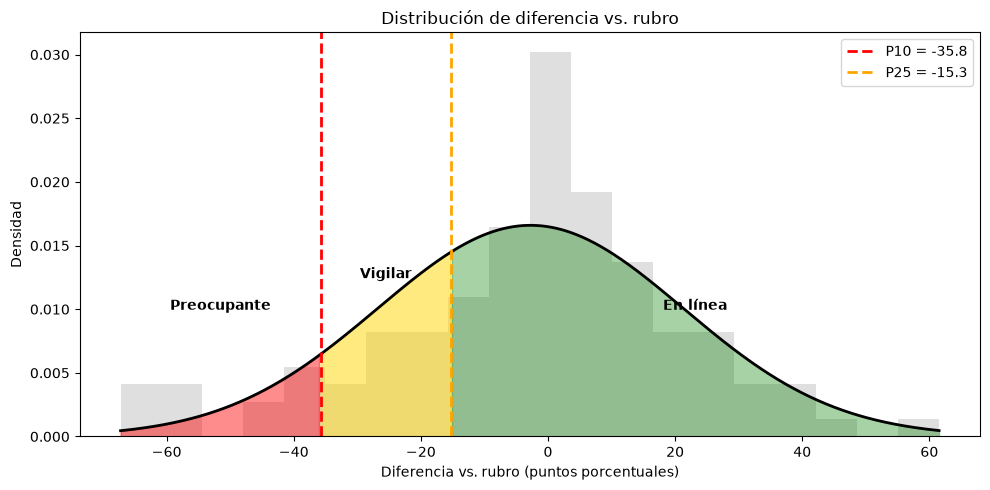

In [1426]:
from scipy.stats import norm
# Datos
datos = cliente_vs_rubro["diferencia_vs_rubro"].dropna()

# Percentiles reales que usamos para clasificar
p10 = datos.quantile(0.10)
p25 = datos.quantile(0.25)

# Media y desviación estándar para ajustar la curva normal
media = datos.mean()
desv = datos.std()

# Valores para dibujar la curva
x = np.linspace(datos.min(), datos.max(), 500)
y = norm.pdf(x, media, desv)

plt.figure(figsize=(10, 5))

# Histograma real de los datos
plt.hist(
    datos,
    bins=20,
    density=True,
    alpha=0.25,
    color="gray"
)

# Curva normal
plt.plot(
    x,
    y,
    color="black",
    linewidth=2
)

# Zona roja: hasta P10
plt.fill_between(
    x,
    y,
    where=(x <= p10),
    color="red",
    alpha=0.45
)

# Zona amarilla: P10 a P25
plt.fill_between(
    x,
    y,
    where=((x > p10) & (x <= p25)),
    color="gold",
    alpha=0.5
)

# Zona verde: sobre P25
plt.fill_between(
    x,
    y,
    where=(x > p25),
    color="green",
    alpha=0.35
)

# Líneas de los percentiles
plt.axvline(
    p10,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"P10 = {p10:.1f}"
)

plt.axvline(
    p25,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"P25 = {p25:.1f}"
)

# Textos de las zonas
altura = y.max()

plt.text(
    (datos.min() + p10) / 2,
    altura * 0.6,
    "Preocupante",
    ha="center",
    fontweight="bold"
)

plt.text(
    (p10 + p25) / 2,
    altura * 0.75,
    "Vigilar",
    ha="center",
    fontweight="bold"
)

plt.text(
    (p25 + datos.max()) / 2,
    altura * 0.6,
    "En línea",
    ha="center",
    fontweight="bold"
)

plt.title("Distribución de diferencia vs. rubro")
plt.xlabel("Diferencia vs. rubro (puntos porcentuales)")
plt.ylabel("Densidad")

plt.legend()
plt.tight_layout()
plt.show()

Gráfica 3: dostribución normal de la diferencias porcentuales vs rubro

Aquí podemos ver que los clientes del extremo izquierdo se catalogan como "preocupante" por su negativa variación con respecto al rubro y los del segmento amarillo se debe vigilar su comportamiento.

Paso 3: revisar los días, las sesiones y los usuarios activos en el panel tiene cada cliente

Ahora es importante ver que tanto dejaron de entrar al panel

In [1427]:
panel_clientes = (
    df_maduros[
        df_maduros["mes"].isin(["2026-07", "2026-08"])
    ]
    .pivot_table(
        index=["cliente_id", "cliente"],
        columns="mes",
        values=[
            "sesiones_panel",
            "dias_activos_panel",
            "usuarios_activos_panel"
        ]
    )
)

display(panel_clientes.head())

dias_activos_panel         sesiones_panel          \
mes                                  2026-07 2026-08        2026-07 2026-08   
cliente_id cliente                                                            
VSU-0001   Andes Mascotas                4.0     9.0            7.0    17.0   
VSU-0002   Andes Montaña                 5.0     4.0            8.0     6.0   
VSU-0004   Aura Bebés                    5.0    14.0            8.0    17.0   
VSU-0006   Aura Muebles                  0.0     0.0            0.0     0.0   
VSU-0007   Aura Solar                    3.0     0.0            6.0     0.0   

                          usuarios_activos_panel          
mes                                      2026-07 2026-08  
cliente_id cliente                                        
VSU-0001   Andes Mascotas                    2.0     3.0  
VSU-0002   Andes Montaña                     2.0     2.0  
VSU-0004   Aura Bebés                        2.0     3.0  
VSU-0006   Aura Muebles                      0.0     0.0  
VSU-0007   Aura Solar                        1.0     0.0

Así vemos los días activos en el panel, las sesiones y los usuarios activos

Ahora buscamos los clientes que llevan 2 meses sin ingresar al panel

In [1428]:
panel_clientes.columns = [
    f"{variable}_{mes}"
    for variable, mes in panel_clientes.columns
]

panel_clientes = panel_clientes.reset_index()

#buscamos detectar a los clientes con cero actividad entre julio y agosto, para ver si hay clientes que no están usando el panel y podrían estar en riesgo de churn.
panel_clientes["sin_panel_2_meses"] = (
    (panel_clientes["sesiones_panel_2026-07"] == 0) &
    (panel_clientes["sesiones_panel_2026-08"] == 0)
)


Ahora los contamos

In [1429]:
print(
    "Clientes sin sesiones de panel durante julio y agosto:",
    panel_clientes["sin_panel_2_meses"].sum()
)

Clientes sin sesiones de panel durante julio y agosto: 12


Obtenemos datos estadísticos de cuánto ingresan los clientes al panel

In [1430]:
display(
    df_maduros[
        df_maduros["mes"].isin(["2026-07", "2026-08"])
    ][
        [
            "sesiones_panel",
            "dias_activos_panel",
            "usuarios_activos_panel"
        ]
    ].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

,sesiones_panel,dias_activos_panel,usuarios_activos_panel
count,226.000000,226.000000,220.000000
mean,10.650442,6.402655,1.981818
std,7.017877,4.590986,1.281992
min,0.000000,0.000000,0.000000
10%,0.000000,0.000000,0.000000
25%,4.000000,3.000000,1.000000
50%,10.500000,6.000000,2.000000
75%,17.000000,9.000000,3.000000
90%,20.500000,13.000000,4.000000
max,22.000000,20.000000,6.000000


Acá se aprecia un porcentaje menor al 25% preocupante

Acá definimos 3 categorías, la de desenganche fuerte, vigilar y sin señal

Vemos primero el percentil que puede crear un punto de inflexión.

In [1431]:
p25_panel_agosto = panel_clientes["sesiones_panel_2026-08"].quantile(0.25)

print("Percentil 25 de sesiones en agosto:", p25_panel_agosto)

Percentil 25 de sesiones en agosto: 4.0


Aquí definimos que si no entran al panel en 2 meses los catalogamos en "Desenganche fuerte", si corresponden al 25% que menos entra al panel y su actividad disminuyó en agosto con respecto a julio se cataloga como "Vigilar". En otro caso los catalogamos como "Sin señal"

In [1432]:
def clasificar_panel(fila):

    # Caso 1: dos meses completos sin entrar al panel
    if (
        fila["sesiones_panel_2026-07"] == 0
        and fila["sesiones_panel_2026-08"] == 0
    ):
        return "Desenganche fuerte"

    # Caso 2: actividad muy baja y además viene disminuyendo
    elif (
        fila["sesiones_panel_2026-08"] <= p25_panel_agosto
        and fila["sesiones_panel_2026-08"]
            < fila["sesiones_panel_2026-07"]
    ):
        return "Vigilar"

    else:
        return "Sin señal"

Los aplicamos a los paneles de los clientes

In [1433]:
panel_clientes["nivel_panel"] = panel_clientes.apply(
    clasificar_panel,
    axis=1
)
#contamos
panel_clientes["nivel_panel"].value_counts()

nivel_panel
Sin señal             86
Vigilar               15
Desenganche fuerte    12
Name: count, dtype: int64

Tenemos valores parecidos a la estimación de alta variación, con 12 en desenganche fuerte, 15 en vigilar y el resto sin señal

Ya tenemos 2 parámetros que definen si hay es problemática la situación del cliente o no

Unimos las tablas de variación con las de entradas al panel

In [1434]:
#unimos las tablas
senales_clientes = cliente_vs_rubro.merge(
    panel_clientes[
        [
            "cliente_id",
            "cliente",
            "nivel_panel",
            "sesiones_panel_2026-07",
            "sesiones_panel_2026-08",
            "dias_activos_panel_2026-07",
            "dias_activos_panel_2026-08"
        ]
    ],
    on=["cliente_id", "cliente"],
    how="left"
)

Obsevamos de manera gráfica cómo se relaciona el nivel de variación con respecto al nivel del panel

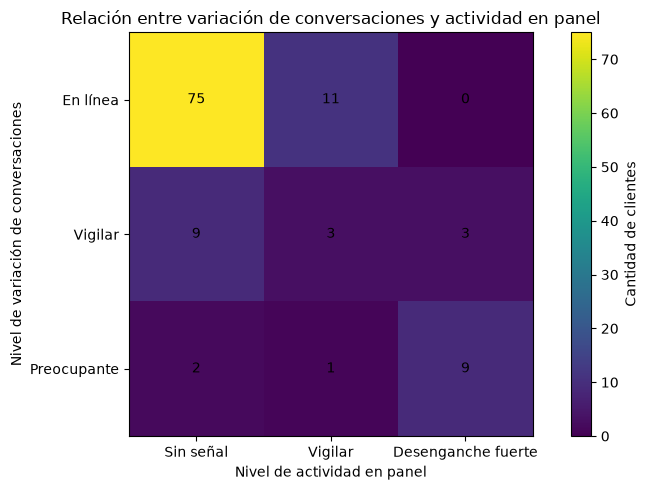

In [1435]:

# Orden lógico de las categorías
orden_variacion = [
    "En línea",
    "Vigilar",
    "Preocupante"
]

orden_panel = [
    "Sin señal",
    "Vigilar",
    "Desenganche fuerte"
]

tabla = pd.crosstab(
    senales_clientes["nivel_variacion"],
    senales_clientes["nivel_panel"]
)

tabla = tabla.reindex(
    index=orden_variacion,
    columns=orden_panel,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 5))

imagen = ax.imshow(tabla.values)

# Ejes
ax.set_xticks(range(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(range(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# Escribir cantidad de clientes dentro de cada celda
for i in range(len(tabla.index)):
    for j in range(len(tabla.columns)):
        ax.text(
            j,
            i,
            tabla.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(
    imagen,
    label="Cantidad de clientes"
)

plt.xlabel("Nivel de actividad en panel")
plt.ylabel("Nivel de variación de conversaciones")

plt.title(
    "Relación entre variación de conversaciones y actividad en panel"
)

plt.tight_layout()
plt.show()

Gráfica 4: relación entre variación de conversaciones y nivel de actividad en panel para clientes maduros

Podemos observar que hay 9 clientes que presentan bajo nivel de conversaciones y baja actividad en el panel, así se pueden relacionar las variables

Procedemos a identificar a estos 9 clientes a los que podemos tomar acción:

In [1436]:
clientes_doble_senal = senales_clientes[
    (senales_clientes["nivel_variacion"] == "Preocupante") &
    (senales_clientes["nivel_panel"] == "Desenganche fuerte")
]["cliente"].tolist()
pd.DataFrame(clientes_doble_senal)

,0
0,Aura Muebles
1,Fauna Bebés
2,Nutri Relojes
3,Quinta Muebles
4,Tostaduría Bike
5,Xilo Zapatos
6,Zafiro Skincare
7,Zafiro Óptica
8,Índigo Labs


Parte 4: ver errores de integración en el sistema

Recordemos que la lista senales_clientes está hecha para clientes maduros pero para detectar errores de integración necesitaremos clienten maduros y nuevos

Revisamos el último mes:

In [1437]:
ultimo_mes = df["mes_dt"].max()

print("Último mes disponible:", ultimo_mes)

Último mes disponible: 2026-09-01 00:00:00


Creamos un DataFrame que incluya los errores de integración, los días de agente inactivo y los mensajes no entregados:

In [1438]:
tecnico_actual = df[
    (df["estado"] == "Activo") &
    (df["mes_dt"] == ultimo_mes)
][
    [
        "cliente_id",
        "cliente",
        "rubro",
        "plan",
        "errores_integracion",
        "dias_agente_inactivo",
        "mensajes_no_entregados"
    ]
].copy()


Obtenemos las medidas estadísticas de estos datos:

In [1439]:
display(
    tecnico_actual[
        [
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados"
        ]
    ].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
)

,errores_integracion,dias_agente_inactivo,mensajes_no_entregados
count,132.000000,132.000000,132.000000
mean,3.280303,0.492424,18.181818
std,10.566629,1.664612,52.860008
min,0.000000,0.000000,0.000000
50%,1.000000,0.000000,3.000000
75%,1.000000,0.000000,10.000000
90%,4.000000,1.000000,34.800000
95%,9.000000,2.000000,58.550000
max,63.000000,10.000000,379.000000


Vemos los 10 casos extemos

In [1440]:
display(
    tecnico_actual.sort_values(
        ["dias_agente_inactivo", "errores_integracion"],
        ascending=False
    ).head(10)
)

,cliente_id,cliente,rubro,plan,errores_integracion,dias_agente_inactivo,mensajes_no_entregados
486,VSU-0115,Urbe Vinos,vinos,Starter,63,10,255
77,VSU-0018,Dunas Andino,nutrición,Pro,51,10,330
528,VSU-0124,Wanda Zapatos,moda,Max,63,8,164
171,VSU-0039,Fiorella Orgánica,nutrición,Starter,57,8,173
129,VSU-0030,Fauna Arte,decohogar,Starter,38,6,379
309,VSU-0074,Lienzo Store,regalos,Pro,1,2,3
386,VSU-0091,Origo Baby,juguetes,Starter,1,2,1
124,VSU-0029,Ergo Vital,nutrición,Pro,0,2,4
422,VSU-0101,Raíz Denim,moda,Starter,0,2,4
538,VSU-0126,Wild Skincare,cosmética,Pro,4,1,9


Ahora veremos los casos más críticos

Vamos a analizar las variables dias_agente_inactivo, errores_integración y mensajes_no_entregados. Así definimos el nivel técnico

CRÍTICO
→ 6 o más días de Agente inactivo
   O
→ 30 o más errores de integración

VIGILAR
→ al menos 1 día de Agente inactivo
   O
→ 4 o más errores de integración
   O
→ 35 o más mensajes no entregados

NORMAL
→ ninguno de los anteriores

Creamos la función para clasificarlos

In [1441]:
def clasificar_salud_tecnica(fila):

    # Problema técnico grave
    if (
        fila["dias_agente_inactivo"] >= 6
        or fila["errores_integracion"] >= 30
    ):
        return "Crítico"

    # Señales que requieren revisión
    elif (
        fila["dias_agente_inactivo"] >= 1
        or fila["errores_integracion"] >= 4
        or fila["mensajes_no_entregados"] >= 35
    ):
        return "Vigilar"

    else:
        return "Normal"


tecnico_actual["nivel_tecnico"] = tecnico_actual.apply(
    clasificar_salud_tecnica,
    axis=1
)

Contamos cuántos clientes entran en cada categoría

In [1442]:
tecnico_actual["nivel_tecnico"].value_counts()

nivel_tecnico
Normal     87
Vigilar    40
Crítico     5
Name: count, dtype: int64

Vemos que tenemos 5 clientes críticos y 40 clientes posibles a vigilar

In [1443]:
display(
    tecnico_actual[
        [
            "cliente",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_tecnico"
        ]
    ].sort_values(
        ["dias_agente_inactivo", "errores_integracion"],
        ascending=False
    )
)

,cliente,errores_integracion,dias_agente_inactivo,mensajes_no_entregados,nivel_tecnico
486,Urbe Vinos,63,10,255,Crítico
77,Dunas Andino,51,10,330,Crítico
528,Wanda Zapatos,63,8,164,Crítico
171,Fiorella Orgánica,57,8,173,Crítico
129,Fauna Arte,38,6,379,Crítico
...,...,...,...,...,...
550,Xilo Arte,0,0,0,Normal
560,Yaku Bike,0,0,7,Normal
575,Zafiro Asados,0,0,0,Normal
590,Zafiro Skincare,0,0,4,Normal


Obtervamos como se relaciona la columna errores_integracion con mensajes_no_entregados a partir de una regresión lineal

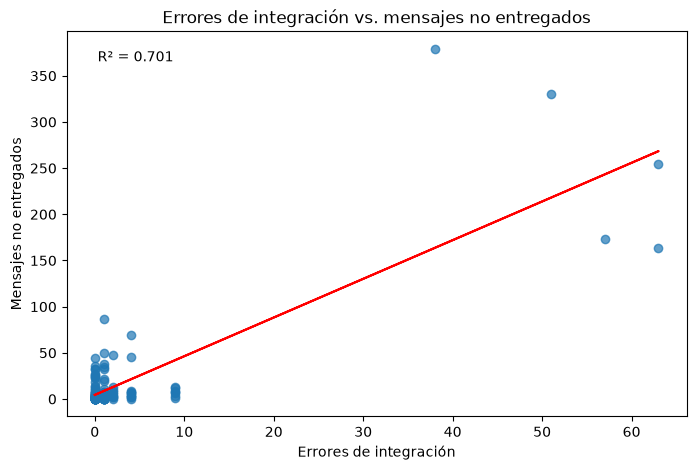

Pendiente: 4.189
Intercepto: 4.441
R²: 0.701


In [1444]:

# Variables

x = tecnico_actual["errores_integracion"]
y = tecnico_actual["mensajes_no_entregados"]

# Regresión lineal
regresion = linregress(x, y)

pendiente = regresion.slope
intercepto = regresion.intercept
r2 = regresion.rvalue**2

# Gráfico
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.7
)

plt.plot(
    x,
    intercepto + pendiente * x,
    color="red"
)

plt.xlabel("Errores de integración")
plt.ylabel("Mensajes no entregados")
plt.title("Errores de integración vs. mensajes no entregados")

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

print(f"Pendiente: {pendiente:.3f}")
print(f"Intercepto: {intercepto:.3f}")
print(f"R²: {r2:.3f}")

Gráfica 5: regresión lineal entre mensajes no entregados y errores de integración.

Podemos concluir a partir de esta regresión lineal que los clientes que presentan muchos errores de integración también presentan muchos mensajes no entregados, para los clientes que tienen pocos errores no existe una relación clara

Por ende se debe también vigilar los mensajes no entregados cuando los errores de integración son altos

Agregamos el nivel_tecnico a senales_clientes haciendo más completo el DataFrame

In [1445]:
senales_clientes = senales_clientes.merge(
    tecnico_actual[
        [
            "cliente_id",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_tecnico"
        ]
    ],
    on="cliente_id",
    how="left"
)

Observamos como queda:

In [1446]:
display(
    senales_clientes[
        [
            "cliente",
            "nivel_variacion",
            "nivel_panel",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_tecnico"
        ]
    ].head()
)

,cliente,nivel_variacion,nivel_panel,errores_integracion,dias_agente_inactivo,mensajes_no_entregados,nivel_tecnico
0,Andes Mascotas,En línea,Sin señal,0,0,1,Normal
1,Andes Montaña,Vigilar,Sin señal,0,0,0,Normal
2,Aura Bebés,En línea,Sin señal,1,0,2,Normal
3,Aura Muebles,Preocupante,Desenganche fuerte,1,0,0,Normal
4,Aura Solar,En línea,Vigilar,0,0,0,Normal


Revisamos si los clientes con más problemas técnicos al mismo tiempo son los que peor variación tienen o tienen bajo nivel de panel:

In [1447]:
display(
    senales_clientes[
        senales_clientes["nivel_tecnico"] == "Crítico"
    ][
        [
            "cliente",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_variacion",
            "nivel_panel"
        ]
    ]
)

,cliente,errores_integracion,dias_agente_inactivo,mensajes_no_entregados,nivel_variacion,nivel_panel
13,Dunas Andino,51,10,330,En línea,Sin señal
23,Fauna Arte,38,6,379,En línea,Sin señal
30,Fiorella Orgánica,57,8,173,En línea,Sin señal
89,Urbe Vinos,63,10,255,En línea,Sin señal
97,Wanda Zapatos,63,8,164,En línea,Sin señal


Aquí vemos que los clientes con más problemas técnicos no necesariamente tienen niveles de variaciones altos

Paso 5: analisis de clientes nuevos que nunca despegaron.

Aislamos los clientes nuevos

In [1448]:
df_nuevos = df[
    (df["estado"] == "Activo") &
    (df["etapa_cliente"] == "Nuevo")
].copy()

print(
    "Clientes nuevos:",
    df_nuevos["cliente_id"].nunique()
)

Clientes nuevos: 19


Resumimos la historia de cada cliente nuevo según el número de conversaciones que tenga

In [1449]:
resumen_nuevos = (
    df_nuevos
    .groupby(
        [
            "cliente_id",
            "cliente",
            "plan",
            "fecha_checkout_dt"
        ]
    )
    .agg(
        meses_con_datos=("mes", "count"),
        conversaciones_promedio=("conversaciones", "mean"),
        conversaciones_max=("conversaciones", "max"),
        sesiones_panel_promedio=("sesiones_panel", "mean"),
        sesiones_panel_max=("sesiones_panel", "max"),
        dias_panel_promedio=("dias_activos_panel", "mean")
    )
    .reset_index()
)

Ahora corregimos el mes de septiembre porque tiene 21 días y hay extrapolar los datos a 30 días

In [1450]:
df_nuevos["conversaciones_ajustadas"] = (
    df_nuevos["conversaciones"].astype(float)
)

mask_sep = df_nuevos["mes"] == "2026-09"

df_nuevos.loc[
    mask_sep,
    "conversaciones_ajustadas"
] = (
    df_nuevos.loc[
        mask_sep,
        "conversaciones"
    ] * 30 / 21
)

Calculamos clientes maduros en septiembre segun plan

In [1451]:
df_maduros_todos = df[
    (df["estado"] == "Activo") &
    (df["etapa_cliente"] == "Maduro")
].copy()

Ajustamos el mes de septiembre para los clientes maduros:

In [1452]:
df_maduros_todos["conversaciones_ajustadas"] = (
    df_maduros_todos["conversaciones"].astype(float)
)

mask_sep_maduros = (
    df_maduros_todos["mes"] == "2026-09"
)

df_maduros_todos.loc[
    mask_sep_maduros,
    "conversaciones_ajustadas"
] = (
    df_maduros_todos.loc[
        mask_sep_maduros,
        "conversaciones"
    ] * 30 / 21
)

Ahora buscamos saber cuantas conversaciones tiene un cliente maduro según su plan, lo definimos como benchmark_plan_sep

In [1453]:
benchmark_plan_sep = (
    df_maduros_todos[
        df_maduros_todos["mes"] == "2026-09"
    ]
    .groupby("plan")
    .agg(
        p25_maduro=("conversaciones_ajustadas", lambda x: x.quantile(0.25)),
        mediana_maduro=("conversaciones_ajustadas", "median"),
        p75_maduro=("conversaciones_ajustadas", lambda x: x.quantile(0.75)),
        clientes_maduros=("cliente_id", "nunique")
    )
    .reset_index()
)

display(benchmark_plan_sep)

,plan,p25_maduro,mediana_maduro,p75_maduro,clientes_maduros
0,Max,2395.714286,3188.571429,4377.142857,25
1,Pro,706.428571,1007.857143,1368.214286,42
2,Starter,100.357143,240.714286,312.142857,46


Vemos el comportamiento de los clientes nuevos en septiembre

In [1454]:
nuevos_sep = df_nuevos[
    df_nuevos["mes"] == "2026-09"
][
    [
        "cliente_id",
        "cliente",
        "plan",
        "fecha_checkout_dt",
        "antiguedad_meses",
        "conversaciones_ajustadas",
        "sesiones_panel",
        "dias_activos_panel"
    ]
].copy()
nuevos_sep = nuevos_sep.merge(
    benchmark_plan_sep,
    on="plan",
    how="left"
)

Obtenemos el porcentaje de las conversaciones de los clientes nuevos con respecto a la mediana de un cliente maduro

In [1455]:
nuevos_sep["pct_vs_mediana_maduro"] = (
    nuevos_sep["conversaciones_ajustadas"]
    / nuevos_sep["mediana_maduro"]
    * 100
)

Observamos gráficamente como se comporta cada cliente nuevo con respecto al nivel de referencia de las conversaciones de los clientes maduros

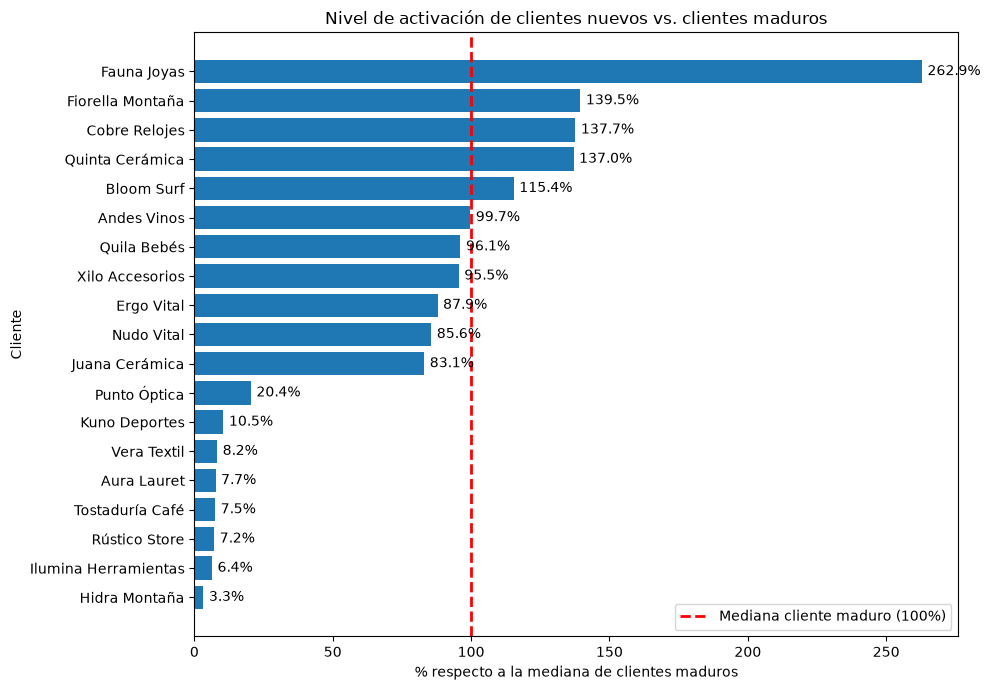

In [1456]:
grafico = nuevos_sep.sort_values(
    "pct_vs_mediana_maduro",
    ascending=True
)

plt.figure(figsize=(10, 7))

barras = plt.barh(
    grafico["cliente"],
    grafico["pct_vs_mediana_maduro"]
)

# Línea de referencia: mediana de clientes maduros
plt.axvline(
    100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mediana cliente maduro (100%)"
)

# Valor al final de cada barra
for barra in barras:
    ancho = barra.get_width()

    plt.text(
        ancho + 2,
        barra.get_y() + barra.get_height()/2,
        f"{ancho:.1f}%",
        va="center"
    )

plt.xlabel("% respecto a la mediana de clientes maduros")
plt.ylabel("Cliente")
plt.title("Nivel de activación de clientes nuevos vs. clientes maduros")

plt.legend()
plt.tight_layout()
plt.show()

Gráfica 6: porcentaje de activación de cada cliente nuevo con respecto a la mediana de los clientes maduros

Podemos ver que hay 8 clientes con muy bajo nivel de conversaciones, dato que es preocupante porque les cuesta integrar bien la IA

Ahora viene la comparación:
“¿Qué tan cerca está este cliente nuevo del nivel de uso típico de un cliente maduro Starter, Pro o Max?”

Clasificamos los clientes en:

Muy reciente: cliente que lleva menos de un mes, no se puede asumir nada sobre su nivel de conversaciones

Baja activación: cliente que no alcanza el 50% de convesaciones del percentil 25 de su plan con respecto a un cliente maduro.

Vigilar: clientes que no alcanza el percentil 25 de los clientes maduros.

En rango: cualquier otro caso

In [1457]:
nuevos_sep["ratio_vs_p25_maduro"] = (
    nuevos_sep["conversaciones_ajustadas"]
    / nuevos_sep["p25_maduro"]
)
def clasificar_activacion(fila):

    # Todavía es demasiado reciente para juzgarlo
    if fila["antiguedad_meses"] < 1:
        return "Muy reciente"

    # No llega ni a la mitad del límite inferior típico
    elif fila["ratio_vs_p25_maduro"] < 0.50:
        return "Baja activación"

    # Está por debajo del rango típico de maduros
    elif fila["ratio_vs_p25_maduro"] < 1:
        return "Vigilar"

    else:
        return "En rango"


nuevos_sep["nivel_activacion"] = nuevos_sep.apply(
    clasificar_activacion,
    axis=1
)

Observamos gráficamente la cantidad de clientes que alcanza cada nivel de activación.

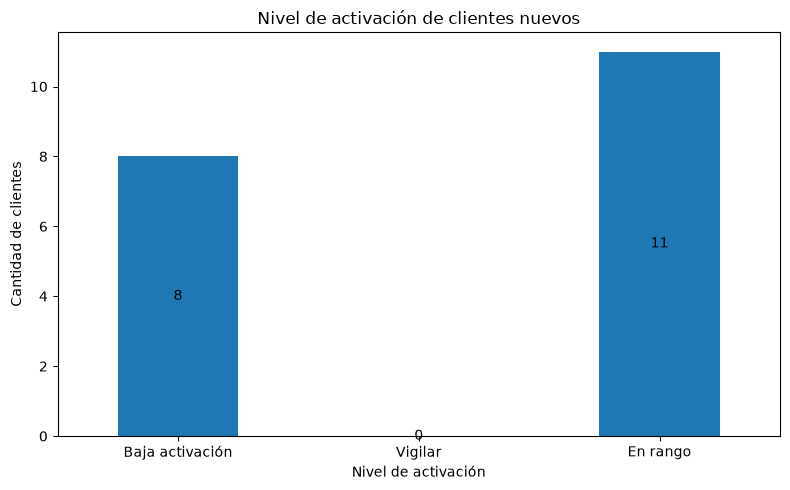

In [1458]:
orden = [
    "Baja activación",
    "Vigilar",
    "En rango"
]

frecuencia_activacion = (
    nuevos_sep["nivel_activacion"]
    .value_counts()
    .reindex(orden, fill_value=0)
)

ax = frecuencia_activacion.plot(
    kind="bar",
    figsize=(8, 5),
    title="Nivel de activación de clientes nuevos"
)

plt.xlabel("Nivel de activación")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

# Número dentro de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center"
    )

plt.tight_layout()
plt.show()

Gráfica 7: cantidad de clientes nuevos según nivel de activación

Como vimos en el gráfico anterior, son 8 clientes nuevos con un nivel muy bajo de activación.

Ahora se ve si los clientes nuevos con baja activación también están usando poco el panel. Se ve si hay relación entre estos parámetros

In [1459]:
benchmark_panel_sep = (
    df_maduros_todos[
        df_maduros_todos["mes"] == "2026-09"
    ]
    .groupby("plan")
    .agg(
        panel_p25_maduro=("sesiones_panel", lambda x: x.quantile(0.25)),
        panel_mediana_maduro=("sesiones_panel", "median"),
        dias_panel_p25_maduro=("dias_activos_panel", lambda x: x.quantile(0.25)),
        dias_panel_mediana_maduro=("dias_activos_panel", "median")
    )
    .reset_index()
)

display(benchmark_panel_sep)

,plan,panel_p25_maduro,panel_mediana_maduro,dias_panel_p25_maduro,dias_panel_mediana_maduro
0,Max,3.0,8.0,2.00,4.0
1,Pro,2.0,7.0,1.25,3.5
2,Starter,0.0,4.0,0.00,2.0


Hacemos un nuevo DataFrame

In [1460]:
nuevos_sep = nuevos_sep.merge(
    benchmark_panel_sep,
    on="plan",
    how="left"
)

Creamos una función para clasificar el uso del panel en:

Sin actividad: no hay sesiones ni dias activos del panel

Baja actividad: no alcanzan el percentil 25 de las sesiones en el panel de los usuarios maduros

En rango: en otro caso

In [1461]:
def clasificar_panel_nuevo(fila):

    # No ha usado el panel en todo el mes
    if (
        fila["sesiones_panel"] == 0
        and fila["dias_activos_panel"] == 0
    ):
        return "Sin actividad"

    # Usa el panel menos que el 25% inferior
    # de clientes maduros de su mismo plan
    elif fila["sesiones_panel"] < fila["panel_p25_maduro"]:
        return "Baja actividad"

    else:
        return "En rango"


nuevos_sep["nivel_panel_nuevo"] = nuevos_sep.apply(
    clasificar_panel_nuevo,
    axis=1
)

Observamos gráficamente como se relacionan los niveles de activación con la cantidad de veces que se entra al panel

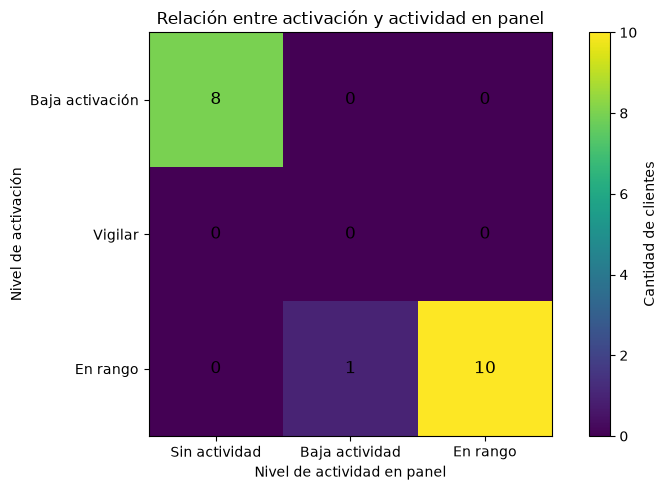

In [1462]:
orden_activacion = [
    "Baja activación",
    "Vigilar",
    "En rango"
]

orden_panel = [
    "Sin actividad",
    "Baja actividad",
    "En rango"
]

tabla = pd.crosstab(
    nuevos_sep["nivel_activacion"],
    nuevos_sep["nivel_panel_nuevo"]
)

tabla = tabla.reindex(
    index=orden_activacion,
    columns=orden_panel,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 5))

imagen = ax.imshow(tabla.values)

ax.set_xticks(range(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(range(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# Frecuencia dentro de cada cuadro
for i in range(len(tabla.index)):
    for j in range(len(tabla.columns)):
        ax.text(
            j,
            i,
            tabla.iloc[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(
    imagen,
    label="Cantidad de clientes"
)

plt.xlabel("Nivel de actividad en panel")
plt.ylabel("Nivel de activación")

plt.title(
    "Relación entre activación y actividad en panel"
)

plt.tight_layout()
plt.show()

Gráfica 8: relación nivel de activacón y nivel de actividad en panel para clientes nuevos.

Aquí se ve un dato preocupante, los 8 clientes que tienen una baja activación al mismo tiempo no tienen actividad en el panel.

Los clasificamos en:

No despega: tiene baja activación y Sin actividad en el panel

Vigilar: tiene vigilar en  nivel de activación o baja actividad en el panel

Activación normal: en otro caso

In [1463]:
def clasificar_cliente_nuevo(fila):

    if (
        fila["nivel_activacion"] == "Baja activación"
        and fila["nivel_panel_nuevo"] == "Sin actividad"
    ):
        return "No despega"

    elif (
        fila["nivel_activacion"] == "Vigilar"
        or fila["nivel_panel_nuevo"] == "Baja actividad"
    ):
        return "Vigilar"

    else:
        return "Activación normal"


nuevos_sep["estado_activacion"] = nuevos_sep.apply(
    clasificar_cliente_nuevo,
    axis=1
)
nuevos_sep["estado_activacion"].value_counts()

estado_activacion
Activación normal    10
No despega            8
Vigilar               1
Name: count, dtype: int64

Volvemos a observar que son 8 clientes que no despegan y solo uno que se debe vigilar

Observamos cuáles son los 8 clientes que no despegan:

In [1464]:
display(
    nuevos_sep[
        nuevos_sep["estado_activacion"] == "No despega"
    ][
        [
            "cliente",
            "plan",
            "antiguedad_meses",
            "conversaciones_ajustadas",
            "pct_vs_mediana_maduro",
            "sesiones_panel",
            "estado_activacion"
        ]
    ]
)

,cliente,plan,antiguedad_meses,conversaciones_ajustadas,pct_vs_mediana_maduro,sesiones_panel,estado_activacion
1,Aura Lauret,Pro,1.806833,77.142857,7.654146,0,No despega
7,Hidra Montaña,Pro,1.182654,32.857143,3.260099,0,No despega
8,Ilumina Herramientas,Pro,2.529566,64.285714,6.378455,0,No despega
10,Kuno Deportes,Pro,2.102497,105.714286,10.489015,0,No despega
12,Punto Óptica,Pro,2.201051,205.714286,20.411056,0,No despega
15,Rústico Store,Max,1.445466,228.571429,7.168459,0,No despega
16,Tostaduría Café,Pro,1.149803,75.714286,7.512403,0,No despega
17,Vera Textil,Pro,2.398160,82.857143,8.221120,0,No despega


observamos que son los mismos 8 clientes con bajo porcentaje de la gráfica 6.

Parte 6: análisis de upsell

Aquí lo ideal es buscar a los clientes que puedan agrandar su plan porque tienen mayor uso de conversaciones del que tienen disponible

Usamos los meses de mayo a agosto y definimos upsell como nuevo dataframe

In [1465]:
limites_plan = {
    "Starter": 300,
    "Pro": 2000,
    "Max": 4000
}

upsell = df[
    (df["estado"] == "Activo") &
    (df["mes"].isin(["2026-05", "2026-06", "2026-07", "2026-08"]))
].copy()

upsell["limite_plan"] = upsell["plan"].map(limites_plan)

upsell["uso_plan_pct"] = (
    upsell["conversaciones"]
    / upsell["limite_plan"]
    * 100
)
upsell_actual = upsell[
    upsell["plan"] == upsell["plan_actual"]
].copy()

Ahora vamos a resumir por cliente

In [1466]:
resumen_upsell = (
    upsell_actual
    .groupby(
        [
            "cliente_id",
            "cliente",
            "plan_actual"
        ]
    )
    .agg(
        meses_datos=("mes", "count"),
        uso_promedio_pct=("uso_plan_pct", "mean"),
        uso_max_pct=("uso_plan_pct", "max"),
        meses_sobre_limite=(
            "uso_plan_pct",
            lambda x: (x > 100).sum()
        )
    )
    .reset_index()
    .rename(columns={"plan_actual": "plan"})
)

Así obtuvimos a partir de los meses un uso promedio para cada cliente comparándolo con su plan

In [1467]:
display(
    resumen_upsell.sort_values(
        ["meses_sobre_limite", "uso_promedio_pct"],
        ascending=False
    )
)

,cliente_id,cliente,plan,meses_datos,uso_promedio_pct,uso_max_pct,meses_sobre_limite
23,VSU-0025,Elqui Labs,Starter,4,194.416667,230.666667,4
7,VSU-0008,Bloom Orgánica,Starter,4,176.333333,218.000000,4
25,VSU-0027,Elqui Textil,Max,4,175.006250,206.025000,4
44,VSU-0047,Granel Skincare,Starter,4,173.333333,198.666667,4
124,VSU-0133,Yaku Streetwear,Starter,4,171.666667,205.666667,4
...,...,...,...,...,...,...,...
109,VSU-0118,Vera Textil,Pro,1,5.400000,5.400000,0
102,VSU-0111,Tostaduría Café,Pro,1,4.500000,4.500000,0
49,VSU-0053,Ilumina Herramientas,Pro,1,3.250000,3.250000,0
4,VSU-0005,Aura Lauret,Pro,1,3.200000,3.200000,0


Aquí podemos ver qué clientes usa más el plan de lo que permite el límite, y así se pueden identificar

El siguiente paso es clasificar la oportunidad de upsell usando dos cosas: cuánto excede el plan y durante cuántos meses lo hace. Definimos la regla inicial:

No aplica
→ tiene el plan max, no hay como subir de categoría

Oportunidad clara
→ estuvo sobre el límite al menos 3 meses
  y además su uso promedio fue >120%

Vigilar upsell
→ estuvo sobre el límite al menos 2 meses
  o su uso promedio fue >100%

Sin oportunidad
→ el resto

In [1468]:
def clasificar_upsell(fila):

    if fila["plan"] == "Max":
        return "No aplica"

    elif (
        fila["meses_sobre_limite"] >= 3
        and fila["uso_promedio_pct"] >= 120
    ):
        return "Oportunidad clara"

    elif (
        fila["meses_sobre_limite"] >= 2
        or fila["uso_promedio_pct"] >= 100
    ):
        return "Vigilar upsell"

    else:
        return "Sin oportunidad"


resumen_upsell["nivel_upsell"] = resumen_upsell.apply(
    clasificar_upsell,
    axis=1
)

Contamos los valores

In [1469]:
resumen_upsell["nivel_upsell"].value_counts()

nivel_upsell
Sin oportunidad      75
No aplica            29
Vigilar upsell       20
Oportunidad clara     8
Name: count, dtype: int64

Viendolo gráficamente:

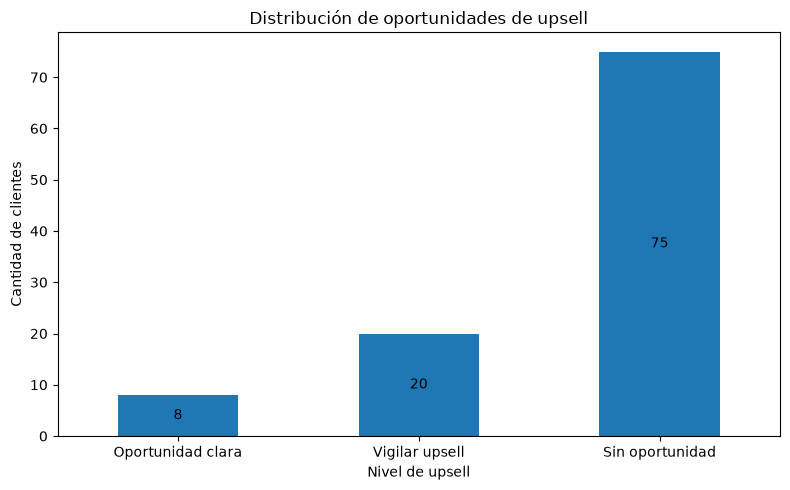

In [1470]:
orden_upsell = [
    "Oportunidad clara",
    "Vigilar upsell",
    "Sin oportunidad"
]

frecuencia_upsell = (
    resumen_upsell["nivel_upsell"]
    .value_counts()
    .reindex(orden_upsell, fill_value=0)
)

ax = frecuencia_upsell.plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribución de oportunidades de upsell"
)

plt.xlabel("Nivel de upsell")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center"
    )

plt.tight_layout()
plt.show()

Gráfica 9: clientes según nivel de upsell

Buscamos los clientes que son candidatos de upsell

In [1471]:
resumen_upsell[
    resumen_upsell["nivel_upsell"] == "Oportunidad clara"
][["cliente"]]

,cliente
7,Bloom Orgánica
23,Elqui Labs
26,Ergo Deportes
32,Fauna Joyas
44,Granel Skincare
60,Kilta Hogar
96,Sable Libros
124,Yaku Streetwear


Acá la logica no es aislada, a partir del comportamiento de todos los meses se define si hay una oportunidad clara de upsell

Ahora hay que definir el impacto económico al lado de la oportunidad de upsell.

Definamos los precios de los planes y calculamos MRR

In [1472]:
siguiente_plan = {
    "Starter": "Pro",
    "Pro": "Max",
    "Max": None
}

precio_plan = {
    "Starter": 149,
    "Pro": 299,
    "Max": 549
}

resumen_upsell["plan_sugerido"] = (
    resumen_upsell["plan"].map(siguiente_plan)
)

resumen_upsell["mrr_actual"] = (
    resumen_upsell["plan"].map(precio_plan)
)

resumen_upsell["mrr_plan_sugerido"] = (
    resumen_upsell["plan_sugerido"].map(precio_plan)
)

resumen_upsell["incremento_mrr_usd"] = (
    resumen_upsell["mrr_plan_sugerido"]
    - resumen_upsell["mrr_actual"]
)

resumen_upsell["incremento_anual_usd"] = (
    resumen_upsell["incremento_mrr_usd"] * 12
)

Así vemos el aumento

Starter → Pro
USD 149 → USD 299
+USD 150/mes

Pro → Max
USD 299 → USD 549
+USD 250/mes

Vemos las oportunidades de upsell, obtenemos datos mensual y anual

In [1473]:
oportunidades_upsell = resumen_upsell[
    resumen_upsell["nivel_upsell"].isin(
        ["Oportunidad clara", "Vigilar upsell"]
    )
].copy()

display(
    oportunidades_upsell[
        [
            "cliente",
            "plan",
            "plan_sugerido",
            "meses_sobre_limite",
            "uso_promedio_pct",
            "nivel_upsell",
            "incremento_mrr_usd",
            "incremento_anual_usd"
        ]
    ].sort_values(
        ["nivel_upsell", "incremento_mrr_usd"],
        ascending=[True, False]
    ).head()
)

,cliente,plan,plan_sugerido,meses_sobre_limite,uso_promedio_pct,nivel_upsell,incremento_mrr_usd,incremento_anual_usd
7,Bloom Orgánica,Starter,Pro,4,176.333333,Oportunidad clara,150.0,1800.0
23,Elqui Labs,Starter,Pro,4,194.416667,Oportunidad clara,150.0,1800.0
26,Ergo Deportes,Starter,Pro,4,125.250000,Oportunidad clara,150.0,1800.0
32,Fauna Joyas,Starter,Pro,4,158.916667,Oportunidad clara,150.0,1800.0
44,Granel Skincare,Starter,Pro,4,173.333333,Oportunidad clara,150.0,1800.0


Vemos una tabla que se ve el plan sugerios, el nivel de oportunidad el incremento de mrr mensual y anual en caso de lograr el upsell

Vemos que para los usuarios que tienen el plan max no se puede vigilar el upsell debido a que no existe un plan mejor.

Sumamos los incrementos

In [1474]:
mrr_potencial_total = oportunidades_upsell["incremento_mrr_usd"].sum()

print("MRR potencial total mensual:", mrr_potencial_total, "USD")
incremento_anual_total = oportunidades_upsell["incremento_anual_usd"].sum()

print("Incremento anual potencial:", incremento_anual_total, "USD")

MRR potencial total mensual: 4900.0 USD
Incremento anual potencial: 58800.0 USD


Separamos entre los que tienen una oportunidad clara y vigilar el upsell

In [1475]:
impacto_upsell = (
    oportunidades_upsell
    .groupby("nivel_upsell")
    .agg(
        clientes=("cliente_id", "nunique"),
        mrr_potencial=("incremento_mrr_usd", "sum"),
        ingreso_anual_potencial=("incremento_anual_usd", "sum")
    )
)

# Agregar fila total
impacto_upsell.loc["Total"] = (
    impacto_upsell[
        [
            "clientes",
            "mrr_potencial",
            "ingreso_anual_potencial"
        ]
    ]
    .sum()
)

display(impacto_upsell)

,clientes,mrr_potencial,ingreso_anual_potencial
nivel_upsell,,,
Oportunidad clara,8.0,1200.0,14400.0
Vigilar upsell,20.0,3700.0,44400.0
Total,28.0,4900.0,58800.0


A partir de esta tabla observamos un mrr potencial para los clientes con oportunidad clara y a los que podemos vigilar su upsell con un total anual de hasta 58.800 USD

Paso 6: consolidar datos

Hay que buscar consolidar todo en una tabla operativa

Clientes maduros
→ nivel_variacion
→ nivel_panel
→ nivel_tecnico

Clientes nuevos
→ nivel_activacion
→ nivel_panel_nuevo
→ estado_activacion

Upsell
→ nivel_upsell
→ plan_sugerido
→ incremento_mrr_usd

Empezamos a preparar clientes antiguos y agregamos la información de upsell en un dataframe llamado maduros_ops

In [1476]:
maduros_ops = senales_clientes.copy()

maduros_ops["etapa"] = "Maduro"

maduros_ops = maduros_ops.merge(
    resumen_upsell[
        [
            "cliente_id",
            "nivel_upsell",
            "plan_sugerido",
            "incremento_mrr_usd"
        ]
    ],
    on="cliente_id",
    how="left"
)

Preparamos los clientes nuevos y los que también tienen oportunidad de upsell

In [1477]:
nuevos_ops = nuevos_sep.copy()

nuevos_ops["etapa"] = "Nuevo"
nuevos_ops = nuevos_ops.merge(
    tecnico_actual[
        [
            "cliente_id",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_tecnico"
        ]
    ],
    on="cliente_id",
    how="left"
)
nuevos_ops = nuevos_ops.merge(
    resumen_upsell[
        [
            "cliente_id",
            "nivel_upsell",
            "plan_sugerido",
            "incremento_mrr_usd"
        ]
    ],
    on="cliente_id",
    how="left"
)

Hacer compatibles las tablas

In [1478]:
maduros_ops["estado_activacion"] = np.nan
nuevos_ops["nivel_variacion"] = np.nan
nuevos_ops["nivel_panel"] = np.nan
#elegimos columnas comunes y se unen
columnas_ops = [
    "cliente_id",
    "cliente",
    "etapa",
    "nivel_variacion",
    "nivel_panel",
    "nivel_tecnico",
    "estado_activacion",
    "nivel_upsell",
    "plan_sugerido",
    "incremento_mrr_usd"
]
lista_ops = pd.concat(
    [
        maduros_ops[columnas_ops],
        nuevos_ops[columnas_ops]
    ],
    ignore_index=True
)

Aquí vemos un resumen de todos los clientes.

In [1479]:
print("Clientes totales:", lista_ops["cliente_id"].nunique())
print("Filas:", len(lista_ops))

Clientes totales: 132
Filas: 132


Para evitar generar duplicados

In [1480]:
maduros_ops = senales_clientes.copy()
maduros_ops["etapa"] = "Maduro"

maduros_ops = maduros_ops.merge(
    resumen_upsell[
        [
            "cliente_id",
            "nivel_upsell",
            "plan_sugerido",
            "incremento_mrr_usd"
        ]
    ],
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

maduros_ops["estado_activacion"] = np.nan

Para nuevos_ops creamos columnas vacías de nivel_variacion y nivel_panel porque no se realizó este análisis para estos clientes

In [1481]:
nuevos_ops = nuevos_sep.copy()
nuevos_ops["etapa"] = "Nuevo"

nuevos_ops = nuevos_ops.merge(
    tecnico_actual[
        [
            "cliente_id",
            "errores_integracion",
            "dias_agente_inactivo",
            "mensajes_no_entregados",
            "nivel_tecnico"
        ]
    ],
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

nuevos_ops = nuevos_ops.merge(
    resumen_upsell[
        [
            "cliente_id",
            "nivel_upsell",
            "plan_sugerido",
            "incremento_mrr_usd"
        ]
    ],
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

nuevos_ops["nivel_variacion"] = np.nan
nuevos_ops["nivel_panel"] = np.nan

Unimos las listas de maduros_ops y nuevos_ops en lista_ops

In [1482]:
columnas_ops = [
    "cliente_id",
    "cliente",
    "etapa",
    "nivel_variacion",
    "nivel_panel",
    "nivel_tecnico",
    "estado_activacion",
    "nivel_upsell",
    "plan_sugerido",
    "incremento_mrr_usd"
]

lista_ops = pd.concat(
    [
        maduros_ops[columnas_ops],
        nuevos_ops[columnas_ops]
    ],
    ignore_index=True
)

Comprobamos que no hayan clientes repetidos

In [1483]:
print("Filas:", len(lista_ops))
print("Clientes únicos:", lista_ops["cliente_id"].nunique())
print("Duplicados:", lista_ops["cliente_id"].duplicated().sum())

Filas: 132
Clientes únicos: 132
Duplicados: 0


Con esto nos aseguramos que no hayan clientes duplicados en caso que contraten 2 planes distintos

Ahora usar los datos para obtener conclusiones para clientes maduros, nuevos, para upsell

Agregar evidencia de clientes maduros

In [1484]:
evidencia_maduros = senales_clientes[
    [
        "cliente_id",
        "variacion_cliente_pct",
        "variacion_rubro_pct",
        "diferencia_vs_rubro",
        "sesiones_panel_2026-07",
        "sesiones_panel_2026-08"
    ]
].copy()

lista_ops = lista_ops.merge(
    evidencia_maduros,
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

Agregamos evidencia técnica

In [1485]:
evidencia_tecnica = tecnico_actual[
    [
        "cliente_id",
        "errores_integracion",
        "dias_agente_inactivo",
        "mensajes_no_entregados"
    ]
].copy()

lista_ops = lista_ops.merge(
    evidencia_tecnica,
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

Agregamos evidencia de activación en clientes nuevos

In [1486]:
evidencia_nuevos = nuevos_sep[
    [
        "cliente_id",
        "pct_vs_mediana_maduro",
        "ratio_vs_p25_maduro",
        "sesiones_panel"
    ]
].copy()

evidencia_nuevos = evidencia_nuevos.rename(
    columns={
        "sesiones_panel": "sesiones_panel_nuevo"
    }
)

lista_ops = lista_ops.merge(
    evidencia_nuevos,
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

Agregar evidencia de upsell

In [1487]:
evidencia_upsell = resumen_upsell[
    [
        "cliente_id",
        "meses_sobre_limite",
        "uso_promedio_pct"
    ]
].copy()

lista_ops = lista_ops.merge(
    evidencia_upsell,
    on="cliente_id",
    how="left",
    validate="one_to_one"
)

Y con esto obtenemos una lista con todos los parámetros vistos anteriormente

In [1488]:
display(lista_ops.head())

,cliente_id,cliente,etapa,nivel_variacion,nivel_panel,nivel_tecnico,estado_activacion,nivel_upsell,plan_sugerido,incremento_mrr_usd,...,sesiones_panel_2026-07,sesiones_panel_2026-08,errores_integracion,dias_agente_inactivo,mensajes_no_entregados,pct_vs_mediana_maduro,ratio_vs_p25_maduro,sesiones_panel_nuevo,meses_sobre_limite,uso_promedio_pct
0,VSU-0001,Andes Mascotas,Maduro,En línea,Sin señal,Normal,NaN,Sin oportunidad,Pro,150.0,...,7.0,17.0,0,0,1,NaN,NaN,NaN,0,79.416667
1,VSU-0002,Andes Montaña,Maduro,Vigilar,Sin señal,Normal,NaN,Sin oportunidad,Pro,150.0,...,8.0,6.0,0,0,0,NaN,NaN,NaN,1,75.000000
2,VSU-0004,Aura Bebés,Maduro,En línea,Sin señal,Normal,NaN,Sin oportunidad,Pro,150.0,...,8.0,17.0,1,0,2,NaN,NaN,NaN,0,68.250000
3,VSU-0006,Aura Muebles,Maduro,Preocupante,Desenganche fuerte,Normal,NaN,Sin oportunidad,Pro,150.0,...,0.0,0.0,1,0,0,NaN,NaN,NaN,0,57.833333
4,VSU-0007,Aura Solar,Maduro,En línea,Vigilar,Normal,NaN,Sin oportunidad,Pro,150.0,...,6.0,0.0,0,0,0,NaN,NaN,NaN,1,75.000000


Transformamos las señales en texto entendible

In [1489]:
def crear_motivo(fila):

    motivos = []

    # ----- CLIENTES MADUROS -----

    if fila["nivel_variacion"] == "Preocupante":
        motivos.append(
            f"Conversaciones {fila['diferencia_vs_rubro']:.1f} pp "
            f"por debajo de la variación de su rubro"
        )

    elif fila["nivel_variacion"] == "Vigilar":
        motivos.append(
            f"Conversaciones {fila['diferencia_vs_rubro']:.1f} pp "
            f"por debajo de su rubro"
        )

    if fila["nivel_panel"] == "Desenganche fuerte":
        motivos.append(
            f"sin actividad relevante en panel: "
            f"{fila['sesiones_panel_2026-07']:.0f} sesiones en julio "
            f"y {fila['sesiones_panel_2026-08']:.0f} en agosto"
        )

    elif fila["nivel_panel"] == "Vigilar":
        motivos.append(
            "actividad de panel en nivel de vigilancia"
        )

    # ----- PROBLEMAS TÉCNICOS -----

    if fila["nivel_tecnico"] == "Crítico":
        motivos.append(
            f"incidente técnico: {fila['dias_agente_inactivo']:.0f} días "
            f"de Agente inactivo, {fila['errores_integracion']:.0f} errores "
            f"y {fila['mensajes_no_entregados']:.0f} mensajes no entregados"
        )

    elif fila["nivel_tecnico"] == "Vigilar":
        motivos.append(
            f"salud técnica a vigilar: "
            f"{fila['errores_integracion']:.0f} errores y "
            f"{fila['dias_agente_inactivo']:.0f} días inactivo"
        )

    # ----- CLIENTES NUEVOS -----

    if fila["estado_activacion"] == "No despega":
        motivos.append(
            f"cliente nuevo con baja activación: alcanza "
            f"{fila['pct_vs_mediana_maduro']:.1f}% del uso mediano "
            f"de un cliente maduro de su plan y registra "
            f"{fila['sesiones_panel_nuevo']:.0f} sesiones de panel"
        )

    elif fila["estado_activacion"] == "Vigilar":
        motivos.append(
            f"cliente nuevo con activación por debajo del rango esperado "
            f"({fila['pct_vs_mediana_maduro']:.1f}% de la mediana madura)"
        )

    # ----- UPSELL -----

    if fila["nivel_upsell"] == "Oportunidad clara":
        motivos.append(
            f"oportunidad de upsell: superó su plan durante "
            f"{fila['meses_sobre_limite']:.0f} meses, con uso promedio "
            f"de {fila['uso_promedio_pct']:.0f}%; potencial "
            f"+USD {fila['incremento_mrr_usd']:.0f} MRR"
        )

    elif fila["nivel_upsell"] == "Vigilar upsell":
        motivos.append(
            f"posible upsell: uso promedio de "
            f"{fila['uso_promedio_pct']:.0f}% del plan"
        )

    if len(motivos) == 0:
        return "Sin señales relevantes"

    return " | ".join(motivos)

Aplicamos en lista_ops

In [1490]:
lista_ops["motivo_contacto"] = lista_ops.apply(
    crear_motivo,
    axis=1
)
display(
    lista_ops[
        [
            "cliente",
            "etapa",
            "motivo_contacto"
        ]
    ].head()
)

,cliente,etapa,motivo_contacto
0,Andes Mascotas,Maduro,Sin señales relevantes
1,Andes Montaña,Maduro,Conversaciones -24.2 pp por debajo de su rubro
2,Aura Bebés,Maduro,Sin señales relevantes
3,Aura Muebles,Maduro,Conversaciones -38.1 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto
4,Aura Solar,Maduro,actividad de panel en nivel de vigilancia


Aquí cada cliente muestra una señal de relevancia dependiendo si presenta algun motivo de contacto

Paso final: definir la prioridad de contacto, que clientes llamar en el corto plazo y cuales en el largo plazo.

Para esto es conveniente asignar puntos a cada señal

VARIACIÓN
Preocupante         = 2,
Vigilar             = 1,
En línea            = 0

PANEL
Desenganche fuerte  = 3,
Vigilar             = 1,
Sin señal           = 0

TÉCNICO
Crítico             = 4,
Vigilar             = 1,
Normal              = 0

CLIENTE NUEVO
No despega          = 4,
Vigilar             = 1,
Activación normal   = 0,
Muy reciente        = 0

UPSELL
Oportunidad clara   = 3,
Vigilar upsell      = 1,
Sin oportunidad     = 0,
No aplica           = 0

In [1491]:
puntaje_variacion = {
    "Preocupante": 2,
    "Vigilar": 1,
    "En línea": 0
}

puntaje_panel = {
    "Desenganche fuerte": 3,
    "Vigilar": 1,
    "Sin señal": 0
}

puntaje_tecnico = {
    "Crítico": 4,
    "Vigilar": 1,
    "Normal": 0
}

puntaje_activacion = {
    "No despega": 4,
    "Vigilar": 1,
    "Activación normal": 0,
    "Muy reciente": 0
}

puntaje_upsell = {
    "Oportunidad clara": 3,
    "Vigilar upsell": 1,
    "Sin oportunidad": 0,
    "No aplica": 0
}

Convertimos cada señal en puntos

In [1492]:
lista_ops["pts_variacion"] = (
    lista_ops["nivel_variacion"]
    .map(puntaje_variacion)
    .fillna(0)
)

lista_ops["pts_panel"] = (
    lista_ops["nivel_panel"]
    .map(puntaje_panel)
    .fillna(0)
)

lista_ops["pts_tecnico"] = (
    lista_ops["nivel_tecnico"]
    .map(puntaje_tecnico)
    .fillna(0)
)

lista_ops["pts_activacion"] = (
    lista_ops["estado_activacion"]
    .map(puntaje_activacion)
    .fillna(0)
)

lista_ops["pts_upsell"] = (
    lista_ops["nivel_upsell"]
    .map(puntaje_upsell)
    .fillna(0)
)

Creamos puntaje final

In [1493]:
lista_ops["puntaje_prioridad"] = (
    lista_ops["pts_variacion"]
    + lista_ops["pts_panel"]
    + lista_ops["pts_tecnico"]
    + lista_ops["pts_activacion"]
    + lista_ops["pts_upsell"]
)

Vemos la tabla con su puntaje de prioridad incluido

In [1494]:
lista_ops[
    [
        "cliente",
        "pts_variacion",
        "pts_panel",
        "pts_tecnico",
        "pts_activacion",
        "pts_upsell",
        "puntaje_prioridad"
    ]
].sort_values(
    "puntaje_prioridad",
    ascending=False
)

,cliente,pts_variacion,pts_panel,pts_tecnico,pts_activacion,pts_upsell,puntaje_prioridad
102,Xilo Zapatos,2.0,3.0,1,0.0,0,6.0
24,Fauna Bebés,2.0,3.0,1,0.0,0,6.0
3,Aura Muebles,2.0,3.0,0,0.0,0,5.0
59,Maderas Juguetes,1.0,3.0,1,0.0,0,5.0
84,Tostaduría Asados,1.0,3.0,0,0.0,1,5.0
...,...,...,...,...,...,...,...
104,Yaku Nutrición,0.0,0.0,0,0.0,0,0.0
115,Bloom Surf,0.0,0.0,0,0.0,0,0.0
119,Fiorella Montaña,0.0,0.0,0,0.0,0,0.0
124,Nudo Vital,0.0,0.0,0,0.0,0,0.0


Asignamos prioridad según puntaje

6+ puntos   → Muy alta prioridad

4-5 puntos → Alta prioridad

2-3 puntos → Prioridad moderada

0-1 puntos → Baja prioridad

In [1495]:
def clasificar_prioridad(puntaje):

    if puntaje >= 6:
        return "Muy alta prioridad"

    elif puntaje >= 4:
        return "Alta prioridad"

    elif puntaje >= 2:
        return "Prioridad moderada"

    else:
        return "Baja prioridad"


lista_ops["prioridad"] = (
    lista_ops["puntaje_prioridad"]
    .apply(clasificar_prioridad)
)

Vemos la lista ordenada de mayor prioridad a menor prioridad

In [1496]:
lista_ops = lista_ops.sort_values(
    "puntaje_prioridad",
    ascending=False
)
display(
    lista_ops[
        [
            "cliente",
            "etapa",
            "prioridad",
            "puntaje_prioridad",
            "motivo_contacto"
        ]
    ]
)

,cliente,etapa,prioridad,puntaje_prioridad,motivo_contacto
102,Xilo Zapatos,Maduro,Muy alta prioridad,6.0,Conversaciones -67.2 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | salud técnica a vigilar: 4 errores y 1 días inactivo
24,Fauna Bebés,Maduro,Muy alta prioridad,6.0,Conversaciones -36.0 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | salud técnica a vigilar: 0 errores y 1 días inactivo
3,Aura Muebles,Maduro,Alta prioridad,5.0,Conversaciones -38.1 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto
59,Maderas Juguetes,Maduro,Alta prioridad,5.0,Conversaciones -33.4 pp por debajo de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | salud técnica a vigilar: 0 errores y 1 días inactivo
84,Tostaduría Asados,Maduro,Alta prioridad,5.0,Conversaciones -19.1 pp por debajo de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | posible upsell: uso promedio de 93% del plan
...,...,...,...,...,...
104,Yaku Nutrición,Maduro,Baja prioridad,0.0,Sin señales relevantes
115,Bloom Surf,Nuevo,Baja prioridad,0.0,Sin señales relevantes
119,Fiorella Montaña,Nuevo,Baja prioridad,0.0,Sin señales relevantes
124,Nudo Vital,Nuevo,Baja prioridad,0.0,Sin señales relevantes


Observamos que hay 2 clientes que hay que hacer revisión de muy alta prioridad

Separamos en 3 listas

In [1497]:
muy_alta_prioridad = lista_ops[
    lista_ops["prioridad"] == "Muy alta prioridad"
].copy()

alta_prioridad = lista_ops[
    lista_ops["prioridad"] == "Alta prioridad"
].copy()

prioridad_moderada = lista_ops[
    lista_ops["prioridad"] == "Prioridad moderada"
].copy()

Observamos cuales son los clientes de muy alta prioridad y el motivo de contacto:

In [1498]:
pd.set_option("display.max_colwidth", None)
display(
    muy_alta_prioridad[
        ["cliente", "motivo_contacto"]
    ]
)


,cliente,motivo_contacto
102,Xilo Zapatos,Conversaciones -67.2 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | salud técnica a vigilar: 4 errores y 1 días inactivo
24,Fauna Bebés,Conversaciones -36.0 pp por debajo de la variación de su rubro | sin actividad relevante en panel: 0 sesiones en julio y 0 en agosto | salud técnica a vigilar: 0 errores y 1 días inactivo


Vemos cuantos clientes quedan en cada lista:

In [1499]:
print("Muy alta prioridad:", len(muy_alta_prioridad))
print("Alta prioridad:", len(alta_prioridad))
print("Prioridad moderada:", len(prioridad_moderada))

Muy alta prioridad: 2
Alta prioridad: 26
Prioridad moderada: 25


Viendolo en un grafico de barras:

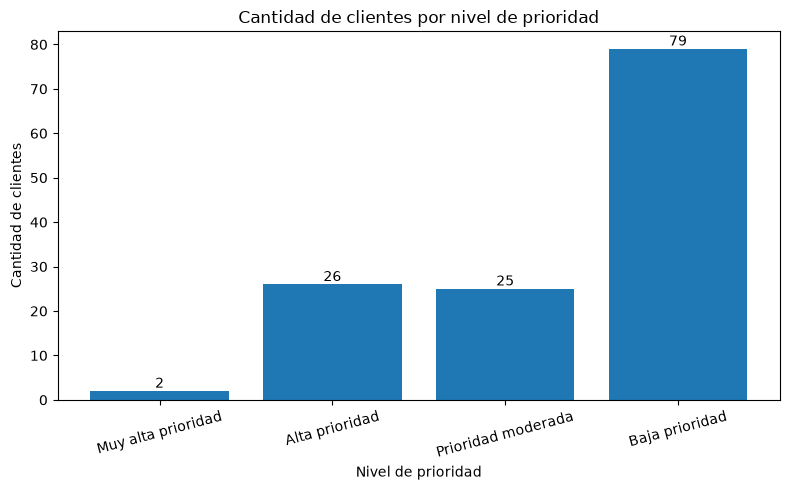

In [1500]:
import matplotlib.pyplot as plt

orden_prioridad = [
    "Muy alta prioridad",
    "Alta prioridad",
    "Prioridad moderada",
    "Baja prioridad"
]

conteo_prioridad = (
    lista_ops["prioridad"]
    .value_counts()
    .reindex(orden_prioridad, fill_value=0)
)

plt.figure(figsize=(8, 5))

barras = plt.bar(
    conteo_prioridad.index,
    conteo_prioridad.values
)

plt.xlabel("Nivel de prioridad")
plt.ylabel("Cantidad de clientes")
plt.title("Cantidad de clientes por nivel de prioridad")

# Mostrar el número encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        str(int(altura)),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Gráfica 10: cantidad de clientes según nivel de prioridad

En la gráfica anterior se observa que hay 2 clientes con muy alta prioridad en ser contactados y 26 clientes con una alta prioridad. Estos clientes presentan una mayor urgencia en ser atendidos por Versu AI.

Conclusiones:

A partir de todo el análisis realizado se confirma que se cumplieron los objetivos propuestos porque se detectaron a los clientes los cuales requieren atención de OPS y se detectaron oportunidades de crecimiento comercial cuantificando el MMR e ingreso potencial.

Dentro de los principales resultados se obtiene:

- 2 clientes con muy alta prioridad de contacto por bajo nivel de conversaciones y que presentan errores técnicos.
- Oportunidad de crecimiento económico de 4900 USD mensual por upsell y de 58800 USD anual.
- 8 de 19 clientes nuevos tienen un nivel de activación bajo reflejado en sus conversaciones, punto que también se debe revisar.

A partir de estos datos se puede encontrar razones para contactar a los clientes pero siempre es necesario y conociendo opiniones, ofrecer servicios técnicos y atender las consultas de los clientes para ir mejorando paulatinamente el servicio